# Multi-Site Monthly Generation

Single-site generators ignore spatial dependencies between gages.
`KirschGenerator` is a nonparametric bootstrap that preserves cross-site
correlations using Cholesky decomposition.

> **Note:** Run this notebook from the `examples/` directory. Figures are saved to `figures/02_multisite/` and data outputs to `outputs/02_multisite/` (both are gitignored).

In [1]:
from pathlib import Path

FIG_DIR = Path("figures") / "02_multisite"
OUT_DIR = Path("outputs") / "02_multisite"
SHARED_DIR = Path("outputs") / "shared"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
SHARED_DIR.mkdir(parents=True, exist_ok=True)

## Fit and generate

In [2]:
import synhydro

Q_daily = synhydro.load_example_data()
Q_monthly = Q_daily.resample("MS").sum()    # all sites, monthly

gen = synhydro.KirschGenerator()
gen.fit(Q_monthly)
ensemble = gen.generate(n_realizations=50, n_years=30, seed=42)

## Verify spatial correlations

The key diagnostic for a multi-site generator is whether pairwise correlations
match the historical record. Side-by-side heatmaps make this easy to assess:

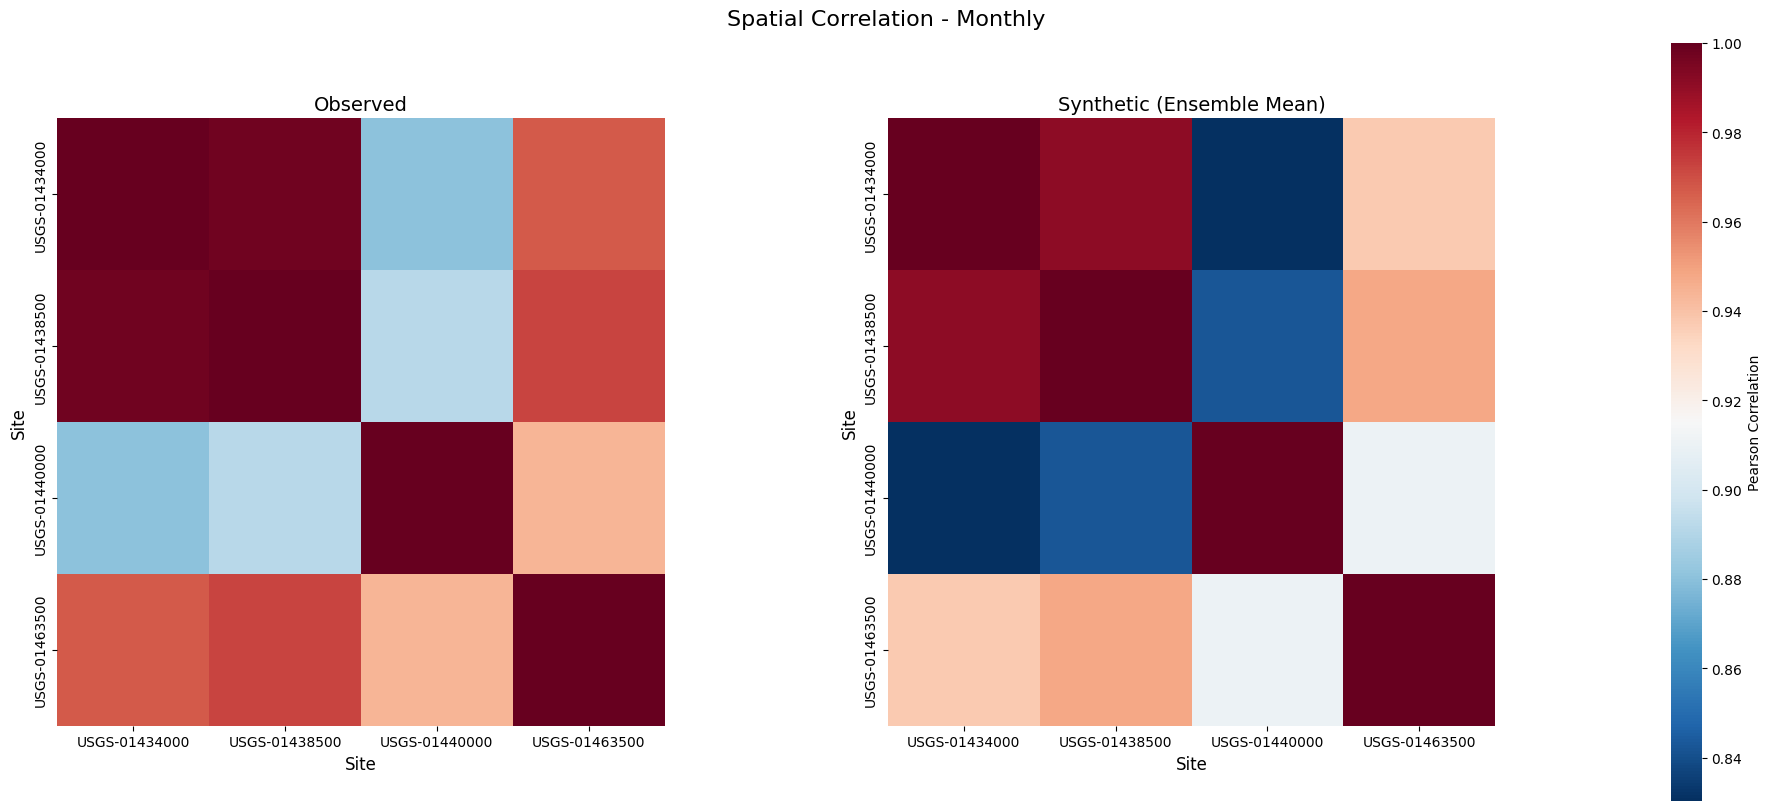

In [3]:
from synhydro.plotting import plot_spatial_correlation

fig, axes = plot_spatial_correlation(
    ensemble,
    observed=Q_monthly,
    timestep="monthly",
)
fig.savefig(FIG_DIR / "spatial_correlation.png", dpi=150, bbox_inches="tight")

## Save for reuse

Later tutorials reuse this monthly ensemble. Save it to the shared outputs
directory so they can load it instead of regenerating:

In [4]:
ensemble.to_hdf5(SHARED_DIR / "kirsch_monthly_ensemble.hdf5", compression="gzip")

## Next steps

- **Monthly-to-daily disaggregation** - [Tutorial 03](../03_disaggregator/)
- **Monthly-to-daily pipeline** - [Tutorial 08](../08_pipeline/)
- **Quantitative validation** - [Tutorial 05](../05_verification/)
- **Algorithm details** - [Kirsch Bootstrap](../../algorithms/kirsch/)

---

**Previous:** [Quickstart (Thomas-Fiering)](../01_quickstart/) | **Next:** [Disaggregator (Nowak)](../03_disaggregator/)